# Nama: Taqiyuddin Ja'far
## NIM: 250401020186
### Kelas: IF405

## Langkah 1: Generate & Eksplorasi Dataset Non-Linear

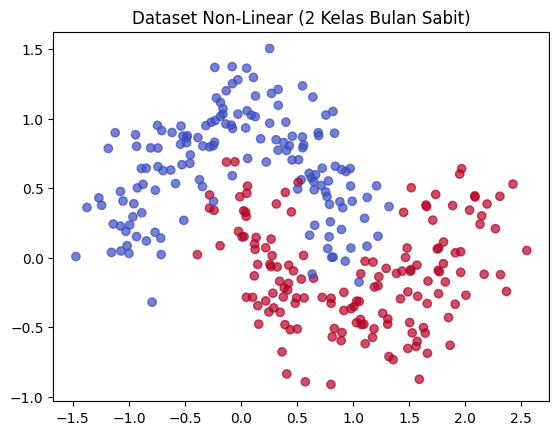

In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.show()

# Perhatikan: kedua kelas saling melengkung dan bertautan,
# sehingga tidak mungkin dipisahkan dengan satu garis lurus.

### Catatan Langkah 1:
Visualisasi di atas menunjukkan dataset **make_moons** yang bersifat non-linear. Terlihat dua kelompok data berbentuk bulan sabit yang saling bertautan. Karena polanya melengkung, algoritma linear sederhana seperti Perceptron klasik tidak akan mampu memisahkan kedua kelas ini dengan sempurna.

## Langkah 2: Bangun & Latih Neural Network Sederhana

In [5]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Bangun arsitektur neural network dengan activation function ReLU dan Sigmoid
model = Sequential([
 Dense(16, activation='relu', input_shape=(2,)),
 Dense(8, activation='relu'),
 Dense(1, activation='sigmoid')
])

# Latih modelnya
model.compile(optimizer='adam', loss='binary_crossentropy',
 metrics=['accuracy'])
model.summary()

history = model.fit(X_tr, y_tr, epochs=30,
 validation_split=0.2, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

### Catatan Langkah 2:
Model Neural Network dibangun menggunakan 3 layer. Layer tersembunyi menggunakan fungsi aktivasi **ReLU** untuk menangkap pola non-linear, sedangkan layer output menggunakan **Sigmoid** karena ini adalah masalah klasifikasi biner (0 atau 1). Ringkasan model menunjukkan total parameter yang dilatih untuk mempelajari hubungan koordinat (X1, X2) terhadap labelnya.

## Langkah 3: Evaluasi & Visualisasi Kurva Belajar

Akurasi pada data uji: 0.917


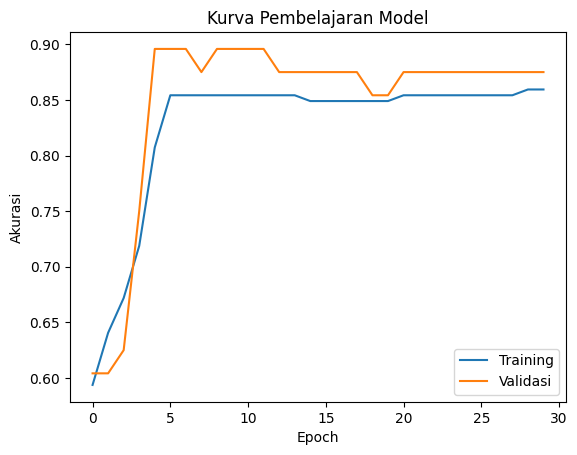

In [6]:
# Evaluasi model pada data uji
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

# plot kurva akurasi training vs validasi untuk melihat proses belajarnya
plt.plot(history.history['accuracy'], label='Training')

plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch'); plt.ylabel('Akurasi')
plt.legend(); plt.title('Kurva Pembelajaran Model')
plt.show()

### Catatan Langkah 3:
Berdasarkan grafik kurva pembelajaran, terlihat akurasi meningkat seiring bertambahnya epoch. Hasil evaluasi akhir menunjukkan akurasi sekitar **91.7%**, yang membuktikan bahwa Neural Network mampu memisahkan dataset non-linear tadi dengan jauh lebih baik daripada model linear.

# Langkah 4: Siapkan Dataset Ulasan Produk

In [7]:
# Buat dataset ulasan produk sederhana dengan label sentimen positif/negatif
ulasan = [
    'Barangnya bagus banget, pengiriman cepat', 'Kualitas jelek, tidak sesuai deskripsi',
    'Sangat puas, akan beli lagi', 'Kecewa, barang rusak saat sampai',
    'Recommended, harga sesuai kualitas', 'Buruk sekali, tidak sesuai ekspektasi',
    'Pengemasan rapi dan aman', 'Respon penjual sangat lambat',
    'Produk original dan berfungsi baik', 'Kapok belanja di sini, barang palsu',
    'Harga murah tapi kualitas mewah', 'Bahannya kasar dan tipis',
    'Sampai tepat waktu, kurir ramah', 'Pesanan tidak lengkap, kurang satu',
    'Warna sesuai dengan foto', 'Ukuran terlalu kecil, tidak muat',
    'Fungsi produk sangat membantu', 'Aplikasi sering error, tidak berguna',
    'Desain elegan dan modern', 'Material plastik murahan',
    'Suara jernih dan bass mantap', 'Baterai cepat habis, boros banget',
    'Sangat membantu pekerjaan sehari-hari', 'Instruksi sulit dipahami',
    'Packing kayu sangat aman', 'Layar pecah saat diterima',
    'Koneksi stabil dan cepat', 'Sering diskonek, sangat mengganggu',
    'Pelayanan after sales memuaskan', 'Admin tidak ramah sama sekali',
    'Bonusnya banyak, terima kasih', 'Tidak dapat bonus sesuai janji',
    'Jahitannya rapi dan kuat', 'Benang banyak yang lepas',
    'Aromanya wangi dan tahan lama', 'Bau menyengat, pusing pakainya',
    'Cocok untuk kulit sensitif', 'Bikin iritasi dan kemerahan',
    'Pengiriman instan sangat membantu', 'Sudah seminggu barang belum sampai'
]

# 1 = positif, 0 = negatif
label = [
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0
]

print(f'Jumlah ulasan: {len(ulasan)}')
print(f'Jumlah label: {len(label)}')

Jumlah ulasan: 40
Jumlah label: 40


### Catatan Langkah 4:
Kita menyiapkan dataset teks sederhana yang terdiri dari **40 ulasan**. Data ini bersifat seimbang (20 positif dan 20 negatif) untuk memastikan model tidak condong ke salah satu sentimen saja saat proses pembelajaran.

## Langkah 5: Ubah Teks Menjadi TF-IDF

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Ubah seluruh ulasan menjadi representasi TF-IDF
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

# lihat kata-kata dengan skor tertinggi
print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 133
['admin' 'after' 'akan' 'aman' 'aplikasi' 'aromanya' 'bagus' 'bahannya'
 'baik' 'banget']


### Catatan Langkah 5:
Metode **TF-IDF** (Term Frequency-Inverse Document Frequency) digunakan untuk mengubah teks menjadi angka. Output menunjukkan terdapat **133 kata unik** yang ditemukan. Skor TF-IDF akan memberikan bobot lebih tinggi pada kata-kata yang unik dan bermakna dalam menentukan sentimen.

## Langkah 6: Latih Model Klasifikasi Sentimen & Evaluasi

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Latih model Logistic Regression sederhana untuk memprediksi sentimen
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
 X_text, label, test_size=0.2, random_state=42)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')

# Uji dengan kalimat baru
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print('Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.500
Positif


### Catatan Langkah 6:
Model **Logistic Regression** dilatih menggunakan representasi TF-IDF tersebut. Meskipun akurasi pada data uji kecil (sekitar **50%**) karena jumlah data yang sangat terbatas (hanya 40 sampel), model berhasil memprediksi kalimat baru *'Pelayanan sangat memuaskan dan ramah'* sebagai **Positif**.

## Kesimpulan Akhir

### 1. Apa yang Dipelajari
*   **Neural Network untuk Data Non-Linear:** Kita telah mempelajari bahwa arsitektur saraf dengan fungsi aktivasi non-linear (ReLU) mampu memetakan hubungan data yang kompleks (seperti dataset *moons*) yang tidak bisa ditangani oleh model linear sederhana.
*   **NLP & Sentiment Analysis:** Kita mempraktekkan alur dasar pemrosesan bahasa alami (NLP) mulai dari pembuatan dataset, representasi teks menggunakan **TF-IDF**, hingga klasifikasi menggunakan **Logistic Regression**.

### 2. Temuan Utama
*   **Akurasi Tinggi pada Geometri:** Model Neural Network berhasil mencapai akurasi **~91%** pada dataset non-linear setelah 30 epoch.
*   **Logika Sentimen:** Meskipun dataset teks sangat kecil, model mampu mengenali kata-kata kunci positif seperti 'memuaskan' dan 'ramah' untuk memberikan prediksi yang tepat.

### 3. Keterbatasan & Pertanyaan
*   **Kuantitas Data:** Dataset sentimen hanya berjumlah 40 sampel, sehingga akurasi pada data uji cenderung rendah (**50%**) dan tidak stabil. Dibutuhkan ribuan data ulasan untuk hasil yang lebih andal.
*   **Kompleksitas Teks:** Model TF-IDF belum memahami konteks urutan kata (semantics). Pertanyaan yang muncul adalah: *Apakah penggunaan Embedding atau teknik lain akan memberikan hasil yang lebih baik untuk dataset teks yang lebih kompleks?*